In [1]:
# Auto-install dependencies (safe to re-run on any machine)
import subprocess, sys
from pathlib import Path

repo = Path.cwd()
if not (repo / 'config.yaml').exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'config.yaml').exists():
            repo = p; break

# Ensure src/ is on the path regardless
src = str(repo / 'src')
if src not in sys.path:
    sys.path.insert(0, src)

# Install package + all dependencies
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-e', str(repo)],
    capture_output=True, text=True
)
if r.returncode == 0:
    print('Package installed OK')
else:
    # Fallback: install deps listed in pyproject.toml individually
    deps = ['numpy>=1.26','pandas>=2.1','pyarrow>=15','scikit-learn>=1.4',
            'joblib>=1.4','httpx>=0.27','PyYAML>=6','catboost>=1.2',
            'statsmodels>=0.14','matplotlib>=3.8']
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + deps,
                   check=True)
    print('Dependencies installed via fallback')


Package installed OK


# ESADE Quant Fund — Quant Appendix (full pipeline)

> **SIMULATED BACKTEST ONLY** — No live or paper trading. All metrics are from historical simulation.

This notebook is the **final deliverable**, but it requires the **whole project** (not just this file): `src/dual8h/`, `config.yaml`, bundled data in `data/raw/`, and cached outputs in `data/experiments/` and `artifacts/`. Open Jupyter from the project root (folder with `config.yaml`).

> **Repository size:** Most of the repo is pre-downloaded market data in `data/raw/` (~90 MB). You can set `DATA_SOURCE = "download"` to fetch from Binance instead, but a full fresh download takes **2+ hours**. See `README.md` for the full list of required files.

This notebook runs the end-to-end research code: **data → features → splits → cadence selection (validation) → production model → hybrid back-test → stress tests**.


## Configuration

| Flag | Meaning |
|------|---------|
| `DATA_SOURCE = "bundled"` | **Option B** — use parquet files in `data/raw/` (included in zip) |
| `DATA_SOURCE = "download"` | **Option A** — fetch from Binance APIs (slow; needs internet) |
| `RUN_SELECTION_SWEEP` | `False` = load cached leaderboard; `True` = retrain all cadence variants (**hours**) |
| `RETRAIN_PRODUCTION_MODEL` | `False` = load frozen model; `True` = purged CV fit on train |
| `FORCE_REBUILD_PANEL` | `False` = reuse `data/experiments/.../panel.parquet` if present |


In [2]:
# --- Pipeline flags (edit before Run All) ---
DATA_SOURCE = "bundled"          # "bundled" | "download"
RUN_SELECTION_SWEEP = False      # True = full cadence grid (very slow)
RETRAIN_PRODUCTION_MODEL = False # True = refit CatBoost on train
FORCE_REBUILD_PANEL = False      # True = rebuild features/panel from raw

import json
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

REPO = Path.cwd()
if not (REPO / "config.yaml").exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config.yaml").exists():
            REPO = p
            break
if not (REPO / "config.yaml").exists():
    raise FileNotFoundError("Open the project root (folder with config.yaml)")

sys.path.insert(0, str(REPO / "src"))

from dual8h.cadence import ExperimentSpec
from dual8h.config import load_config
from dual8h.experiments.granularity_sweep import (
    PRODUCTION_TAG,
    _exp_dir,
    build_panel_for_experiment,
    build_splits_for_experiment,
    focused_selection_experiments,
    pick_best,
    run_selection_sweep,
)
from dual8h.features.exec_panel_1h import build_exec_panel_1h, build_exec_splits_1h
from dual8h.ingest.run import run_ingest
from dual8h.pipeline.catboost_train import catboost_params, train_reg_catboost
from dual8h.pipeline.production_8h import experiment_spec, ensure_model_trained
from dual8h.pipeline.production_hybrid import run_production_hybrid
from dual8h.reports.appendix_metrics import (
    equity_curve,
    hybrid_sleeve_metrics,
    performance_table,
    stress_subperiod,
)
from dual8h.strategy.simulator import _BARS_PER_YEAR

PROFILE = "wide20_8h_dual"
cfg = load_config(profile=PROFILE)
exp = experiment_spec(cfg)
BPY = _BARS_PER_YEAR["1h"]
print("Repo:", REPO)
print("DATA_SOURCE:", DATA_SOURCE)
print("Production cadence:", PRODUCTION_TAG)


Repo: c:\Users\toni\Desktop\FinalProject
DATA_SOURCE: bundled
Production cadence: 8h_fwd5d


## 1. Data ingest

**Option A — download from scratch:** set `DATA_SOURCE = "download"` (or delete `data/raw/ohlcv/*` and `data/raw/funding/*` first).

**Option B — bundled databases:** set `DATA_SOURCE = "bundled"`. Existing parquet files are kept; ingest only fills gaps.


In [3]:
raw_ohlcv = cfg.data_dir("raw", "ohlcv")
raw_funding = cfg.data_dir("raw", "funding")
n_ohlcv = len(list(raw_ohlcv.glob("*.parquet"))) if raw_ohlcv.exists() else 0
n_fund = len(list(raw_funding.glob("*.parquet"))) if raw_funding.exists() else 0
print(f"Before ingest: {n_ohlcv} OHLCV files, {n_fund} funding files")

if DATA_SOURCE == "download":
    print("Option A: fetching from Binance (this may take a long time)...")
    run_ingest(cfg, force_fetch=True)
else:
    print("Option B: using bundled raw data (skip API where files exist)...")
    run_ingest(cfg, force_fetch=False)

n_ohlcv = len(list(raw_ohlcv.glob("*.parquet")))
n_fund = len(list(raw_funding.glob("*.parquet")))
assert n_ohlcv > 0 and n_fund > 0, "No raw data — use bundled zip or DATA_SOURCE='download'"
print(f"After ingest: {n_ohlcv} OHLCV, {n_fund} funding")

sample = pd.read_parquet(raw_ohlcv / f"{cfg.symbols[0]}_8h.parquet")
display(sample.head(3))
print("Columns:", list(sample.columns))


INFO | Legacy research repo not found; skip bootstrap.
INFO | Ingest complete (0 OHLCV series written/updated).


Before ingest: 40 OHLCV files, 20 funding files
Option B: using bundled raw data (skip API where files exist)...
After ingest: 40 OHLCV, 20 funding


,timestamp,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume
0,2018-06-01 00:00:00+00:00,7485.01,7608.55,7454.35,7572.09,9050.913495,6.799329e+07,92604,5265.022371,3.954324e+07
1,2018-06-01 08:00:00+00:00,7572.09,7599.99,7355.54,7447.30,11319.483214,8.465298e+07,107704,6156.138742,4.606531e+07
2,2018-06-01 16:00:00+00:00,7447.30,7540.00,7388.03,7521.01,7888.727369,5.881224e+07,102761,4280.044318,3.190831e+07


Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'trade_count', 'taker_buy_base_volume', 'taker_buy_quote_volume']


## 2. Feature engineering & panel (8h)

Per symbol: align funding → per-asset features (FFD log close, momentum, RV, EMAs) → cross-sectional ranks → forward 5d target.

**Cleaning:** `filter_to_universe` + `filter_common_history` (drop symbols/bars with missing features).


In [4]:
panel_path = _exp_dir(cfg, exp, "panel.parquet")
if FORCE_REBUILD_PANEL or not panel_path.exists():
    print("Building panel:", exp.tag)
    build_panel_for_experiment(cfg, exp)
else:
    print("Reusing panel:", panel_path)

panel = pd.read_parquet(panel_path)
feat_cols = cfg.model_features
print("Panel rows:", len(panel), "| timestamps:", panel["timestamp"].nunique())
print("Features:", feat_cols)
display(panel[feat_cols + [exp.target_col, "symbol", "timestamp"]].head(5))


Reusing panel: C:\Users\toni\Desktop\FinalProject\data\experiments\wide20_8h_dual\8h_fwd5d\panel.parquet
Panel rows: 112540 | timestamps: 5627
Features: ['three_ema_y2', 'ffd_log_close', 'mom_30d', 'mom_7d', 'mom_4h', 'funding_rate_7d_median', 'funding_rate_xs_rank', 'rv_close_30d', 'rv_garman_klass_30d', 'signed_taker_imbalance']


,three_ema_y2,ffd_log_close,mom_30d,mom_7d,mom_4h,funding_rate_7d_median,funding_rate_xs_rank,rv_close_30d,rv_garman_klass_30d,signed_taker_imbalance,fwd_logret_5d,symbol,timestamp
0,0.274424,0.974980,0.064283,-0.033161,-0.001726,0.000404,14.0,0.353301,0.040554,-0.022497,0.116807,AAVEUSDT,2021-03-29 08:00:00+00:00
1,2.124791,-0.233204,-0.123652,0.019140,-0.004041,0.000550,15.0,0.359773,0.043860,-0.042968,0.002889,ADAUSDT,2021-03-29 08:00:00+00:00
2,1.278454,0.157832,0.033151,-0.026585,0.028435,0.000279,18.0,0.349294,0.043343,0.020873,0.071217,ATOMUSDT,2021-03-29 08:00:00+00:00
3,0.796268,0.108256,0.126563,-0.084138,0.009681,0.000645,20.0,0.449222,0.056749,0.012475,0.023465,AVAXUSDT,2021-03-29 08:00:00+00:00
4,0.169628,0.605256,0.064540,-0.025627,0.018932,0.000176,6.0,0.254286,0.031267,0.007178,0.086058,BCHUSDT,2021-03-29 08:00:00+00:00


## 3. Train / validation / test splits (calendar + purge)


In [5]:
split_dir = _exp_dir(cfg, exp, "splits")
if FORCE_REBUILD_PANEL or not (split_dir / "train.parquet").exists():
    build_splits_for_experiment(cfg, exp)

splits = {}
for name in ("train", "validation", "test"):
    df = pd.read_parquet(split_dir / f"{name}.parquet")
    splits[name] = df
    print(f"{name:12s} rows={len(df):6d}  ts={df['timestamp'].nunique():5d}  "
          f"{df['timestamp'].min()} → {df['timestamp'].max()}")

pd.DataFrame({
    "split": list(splits),
    "rows": [len(splits[k]) for k in splits],
    "symbols": [splits[k]["symbol"].nunique() for k in splits],
})


train        rows= 60060  ts= 3003  2021-03-29 08:00:00+00:00 → 2023-12-25 00:00:00+00:00
validation   rows= 21560  ts= 1078  2024-01-01 00:00:00+00:00 → 2024-12-25 00:00:00+00:00
test         rows= 30120  ts= 1506  2025-01-01 00:00:00+00:00 → 2026-05-17 16:00:00+00:00


,split,rows,symbols
0,train,60060,20
1,validation,21560,20
2,test,30120,20


## 4. Bar-frequency screening — why 8h bars

Before choosing a forecast horizon we fix the **sampling frequency**. We resample the 1h tape to 2h / 4h / 8h / 12h bars, rebuild the model's price features with **time-matched lookbacks**, and measure the cross-sectional **rank Information Coefficient** (Spearman IC of each signal vs. the forward 5-day return) on the **train window only**. The composite is the sign-aligned average of the per-feature signals.

Two things decide the choice: (i) which frequency carries the most cross-sectional signal — mean IC and its information ratio (mean IC / std IC); and (ii) the economic prior that **Binance perpetual funding settles every 8h**, so 8h bars align one-to-one with funding events — finer bars split a funding period, coarser bars merge them.

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Loading cached bar-frequency screen: C:\Users\toni\Desktop\FinalProject\artifacts\experiments\wide20_8h_dual\bar_frequency_screen.csv
Highest composite IC: 8h   |   highest composite IC-IR: 8h


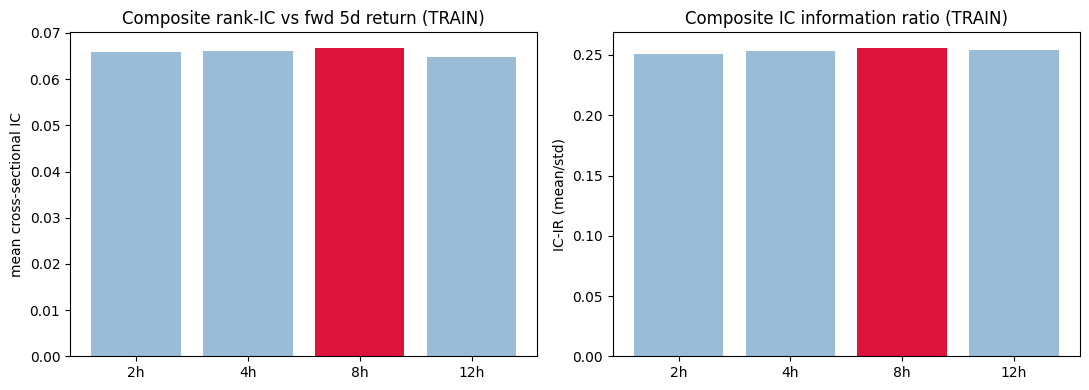

,interval,n_bars,IC_composite,ICIR_composite,absIC_mean
0,2h,12093,0.0659,0.251,0.0228
1,4h,6048,0.0660,0.253,0.0220
2,8h,3024,0.0668,0.256,0.0223
3,12h,2016,0.0647,0.254,0.0220


In [6]:
from dual8h.experiments.bar_frequency_screen import screen_bar_frequencies

RUN_BAR_FREQ_SCREEN = False   # True = recompute the IC screen from the 1h tape (slow)
screen_path = cfg.artifact_dir("experiments", PROFILE, "bar_frequency_screen.csv")

if RUN_BAR_FREQ_SCREEN or not screen_path.exists():
    print("Screening bar frequencies on TRAIN window (2h/4h/8h/12h)...")
    screen = screen_bar_frequencies(cfg, intervals=(2, 4, 8, 12))
    screen.to_csv(screen_path, index=False)
else:
    print("Loading cached bar-frequency screen:", screen_path)
    screen = pd.read_csv(screen_path)

order = {"2h": 0, "4h": 1, "8h": 2, "12h": 3}
screen = screen.sort_values("interval", key=lambda s: s.map(order)).reset_index(drop=True)
best_ic = screen.loc[screen["IC_composite"].idxmax(), "interval"]
best_ir = screen.loc[screen["ICIR_composite"].idxmax(), "interval"]
print(f"Highest composite IC: {best_ic}   |   highest composite IC-IR: {best_ir}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = ["crimson" if iv == "8h" else "#9bbcd6" for iv in screen["interval"]]
ax[0].bar(screen["interval"], screen["IC_composite"], color=colors)
ax[0].set_title("Composite rank-IC vs fwd 5d return (TRAIN)"); ax[0].set_ylabel("mean cross-sectional IC")
ax[1].bar(screen["interval"], screen["ICIR_composite"], color=colors)
ax[1].set_title("Composite IC information ratio (TRAIN)"); ax[1].set_ylabel("IC-IR (mean/std)")
plt.tight_layout(); plt.show()

display(screen[["interval", "n_bars", "IC_composite", "ICIR_composite", "absIC_mean"]])

**Conclusion.** Cross-sectional signal is broadly flat across sampling frequencies (composite IC ≈ 0.065–0.067), but **8h is the peak on both composite IC (≈ 0.067) and the IC information ratio (≈ 0.26)** while sampling 4× slower than 2h — i.e. less turnover and trading cost for marginally *more* signal. Together with the funding-cadence alignment (8h = one funding event per bar), 8h is the justified production frequency. We fix 8h bars and select the forecast horizon within the 8h family next.

## 5. Horizon selection within 8h (validation only)

With the 8h frequency fixed (Section 4), we pick the forecast/rebalance horizon among the seven 8h candidates (fwd1d–fwd7d). **Ranking uses validation Sharpe-to-max-drawdown only** (`validation_sharpe_dd = validation sleeve Sharpe / |max DD|`); the test split is held out (evaluated once, later).

Production choice: **`8h_fwd5d`** — rank 1 of the seven on this risk-adjusted criterion.

Loading cached selection leaderboard: C:\Users\toni\Desktop\FinalProject\artifacts\experiments\wide20_8h_dual\selection_leaderboard.csv
Selected in 8h family: 8h_fwd5d  (validation_sharpe_dd=12.39)
Production tag:        8h_fwd5d  (validation_sharpe_dd=12.39)


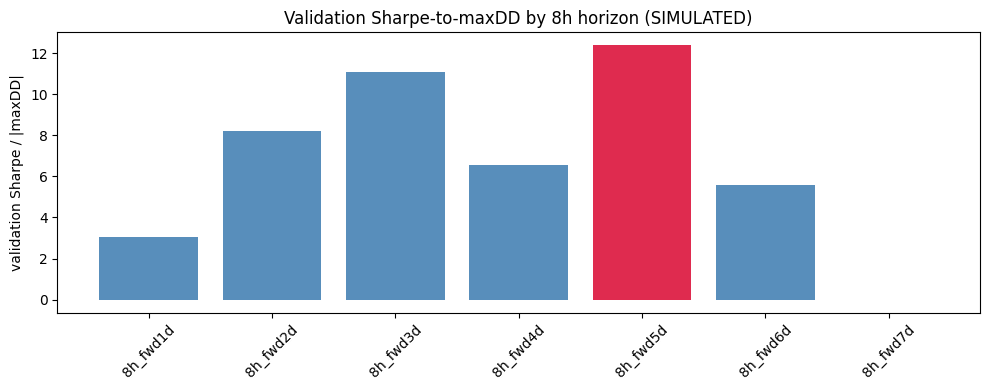

,tag,interval,target_days,selectable,rank_by_validation_sharpe_dd,validation_sleeve_sharpe,validation_max_dd,validation_sharpe_dd
0,8h_fwd5d,8h,5,True,1,0.953926,-0.077011,12.386899
1,8h_fwd3d,8h,3,True,2,1.045250,-0.094534,11.056876
2,8h_fwd2d,8h,2,True,3,0.818966,-0.099587,8.223620
3,8h_fwd4d,8h,4,True,4,0.626667,-0.095653,6.551491
4,8h_fwd6d,8h,6,True,5,0.633169,-0.113900,5.559015
5,8h_fwd1d,8h,1,True,6,0.347965,-0.114751,3.032354
6,8h_fwd7d,8h,7,True,7,-0.001170,-0.088861,-0.013162


In [7]:
leaderboard_path = cfg.artifact_dir("experiments", PROFILE, "selection_leaderboard.csv")

if RUN_SELECTION_SWEEP:
    print("Running full selection sweep (slow)...")
    lb = run_selection_sweep(cfg)   # 8h-family horizons only
else:
    if leaderboard_path.exists():
        print("Loading cached selection leaderboard:", leaderboard_path)
        lb = pd.read_csv(leaderboard_path)
    else:
        raise FileNotFoundError(
            "No selection_leaderboard.csv — set RUN_SELECTION_SWEEP=True once, or ship artifacts."
        )

CRIT = "validation_sharpe_dd"
if CRIT not in lb.columns:
    lb[CRIT] = lb["validation_sleeve_sharpe"] / lb["validation_max_dd"].abs()

best = pick_best(lb, rank_col=CRIT)            # 8h family only, ranked by Sharpe/maxDD
prod_row = lb[lb["tag"] == PRODUCTION_TAG].iloc[0]
print(f"Selected in 8h family: {best['tag']}  ({CRIT}={best[CRIT]:.2f})")
print(f"Production tag:        {PRODUCTION_TAG}  ({CRIT}={prod_row[CRIT]:.2f})")

fam = lb[lb["interval"] == "8h"].sort_values("target_days")
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["crimson" if t == PRODUCTION_TAG else "steelblue" for t in fam["tag"]]
ax.bar(fam["tag"], fam[CRIT], color=colors, alpha=0.9)
ax.set_title("Validation Sharpe-to-maxDD by 8h horizon (SIMULATED)")
ax.set_ylabel("validation Sharpe / |maxDD|")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

cols = [c for c in ["tag", "interval", "target_days", "selectable",
        "rank_by_validation_sharpe_dd", "validation_sleeve_sharpe",
        "validation_max_dd", "validation_sharpe_dd"] if c in lb.columns]
display(lb.sort_values(CRIT, ascending=False)[cols].head(12))

### Why `8h_fwd5d`?

- **Rank 1 in the 8h family on validation Sharpe-to-max-drawdown** (≈ 12.4) — the pre-registered criterion.
- `8h_fwd3d` has a higher *raw* validation Sharpe (1.05 vs 0.95) but a deeper drawdown (−9.5% vs −7.7%); fwd5d wins once risk-adjusted.
- 5d / 15-bar horizon balances perp-funding carry and the ML signal.
- **Test** is reported once below (held-out `holdout_test_evaluation.csv`) and was not used for this choice.

## 6. Production model (CatBoost, train split only)

In [8]:
print("CatBoost config:", json.dumps(catboost_params(cfg), indent=2))
print("Sleeve weights (frozen):", cfg.sleeve_weights)

model, train_info = ensure_model_trained(cfg, exp, retrain=RETRAIN_PRODUCTION_MODEL)
if train_info:
    display(pd.Series(train_info))
else:
    print("Loaded frozen model from artifacts/models/")


INFO | Loading frozen model from C:\Users\toni\Desktop\FinalProject\artifacts\models\wide20_8h_dual\catboost_reg.joblib (train split only was used for fit)


CatBoost config: {
  "iterations_grid": [
    100,
    200
  ],
  "depth": 2,
  "learning_rate": 0.05,
  "min_data_in_leaf": 150,
  "n_splits": 5,
  "purge_days": 7,
  "embargo_pct": 0.01
}
Sleeve weights (frozen): (0.35, 0.65)
Loaded frozen model from artifacts/models/


## 7. Hybrid execution panel (1h PnL) & back-test

In [9]:
print("Building 1h execution panel for hybrid simulator...")
build_exec_panel_1h(cfg, exp_tag=exp.tag)
build_exec_splits_1h(cfg, exp_tag=exp.tag)

prod_summary = run_production_hybrid(cfg, fetch=False, retrain=False)
display(prod_summary[[
    "split", "mode", "sleeve_sharpe", "ml_sharpe", "carry_sharpe",
    "sleeve_max_dd_log", "n_bars",
]])


INFO | 1h exec panel already cached, skipping rebuild (C:\Users\toni\Desktop\FinalProject\data\experiments\wide20_8h_dual\8h_fwd5d\1h_exec\panel.parquet)


Building 1h execution panel for hybrid simulator...


INFO | Canonical production 8h_fwd5d / 8h_decide_1h_exec
INFO | Loading frozen model from C:\Users\toni\Desktop\FinalProject\artifacts\models\wide20_8h_dual\catboost_reg.joblib (train split only was used for fit)
INFO | 1h exec panel already cached, skipping rebuild (C:\Users\toni\Desktop\FinalProject\data\experiments\wide20_8h_dual\8h_fwd5d\1h_exec\panel.parquet)
INFO | 8h_fwd5d validation: sleeve=0.942 ml=0.713 carry=0.832 n_bars=8615
INFO | 8h_fwd5d test: sleeve=1.695 ml=1.114 carry=1.621 n_bars=12039


,split,mode,sleeve_sharpe,ml_sharpe,carry_sharpe,sleeve_max_dd_log,n_bars
0,validation,8h_decide_1h_exec,0.941806,0.713000,0.832242,-0.077821,8615
1,test,8h_decide_1h_exec,1.695035,1.114049,1.620824,-0.077549,12039


## 8. Full metrics — CAGR, vol, Sharpe, max DD, turnover (simulated)

| | |
|---|---|
| Data | Binance USDT-M, 20 symbols |
| Look-ahead | Purged CV on train; val for selection; test once |
| Execution | 8h decide, 1h PnL, 1-bar lag |

In [10]:
res = cfg.artifact_dir("results", PROFILE)
val_bars = pd.read_parquet(res / "validation_catboost_reg_bars.parquet")
test_bars = pd.read_parquet(res / "test_catboost_reg_bars.parquet")

val_panel = pd.read_parquet(_exp_dir(cfg, exp, "splits", "validation.parquet"))
test_panel = pd.read_parquet(_exp_dir(cfg, exp, "splits", "test.parquet"))
from dual8h.features.exec_panel_1h import exec_1h_dir
exec_val = pd.read_parquet(exec_1h_dir(cfg, exp.tag) / "splits" / "validation.parquet")
exec_test = pd.read_parquet(exec_1h_dir(cfg, exp.tag) / "splits" / "test.parquet")

metrics = {
    "validation": hybrid_sleeve_metrics(
        cfg, exp, val_panel, exec_val, model, cfg.model_features, split="validation",
    ),
    "test": hybrid_sleeve_metrics(
        cfg, exp, test_panel, exec_test, model, cfg.model_features, split="test",
    ),
}

def fmt_table(d):
    return {
        "split": d.get("split"),
        "cagr_%": round(100 * d["cagr"], 2),
        "ann_vol_%": round(100 * d["ann_vol"], 2),
        "sharpe": round(d["sharpe"], 3),
        "max_dd_%": round(d["max_dd_pct"], 2),
        "turnover_ann": round(d["annualized_turnover_proxy"], 3) if "annualized_turnover_proxy" in d else None,
        "hit_rate": round(d["hit_rate"], 3),
        "n_bars": d["n_bars"],
    }

display(pd.DataFrame([fmt_table(metrics["validation"]), fmt_table(metrics["test"])]))


,split,cagr_%,ann_vol_%,sharpe,max_dd_%,turnover_ann,hit_rate,n_bars
0,validation,11.29,11.36,0.942,-7.78,22.993,0.507,8615
1,test,21.74,11.60,1.695,-7.75,23.318,0.513,12039


### Benchmark — vs a passive S&P 500 allocation

The strategy is **SIMULATED**; the S&P 500 series is **real** public index data (Yahoo Finance, `^GSPC` daily closes, bundled at `data/raw/benchmark/SPX_daily.csv`) used only as a passive benchmark over the **identical** test window. Each book is annualised at its native sampling frequency (strategy = hourly bars; S&P = 252 trading days); the S&P is flat on days it is closed, so the strategy curve reflects its true 7-day cumulative.

Test window 2025-01-01 -> 2026-05-17  |  source: Yahoo Finance ^GSPC daily closes
Strategy vs S&P 500 (daily): correlation -0.26, beta -0.15


,book,cagr_%,vol_%,sharpe,max_dd_%
0,"Basis8 (net, SIMULATED)",21.7,11.6,1.70,-7.5
1,S&P 500 buy & hold,18.6,17.5,0.98,-18.9


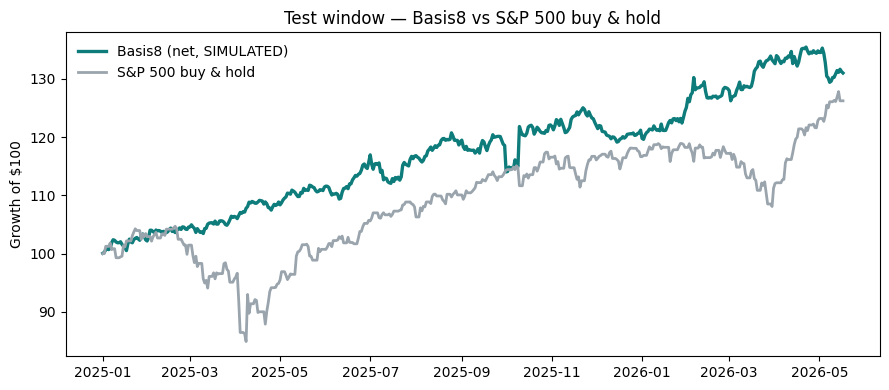

In [11]:
from dual8h.reports.benchmark import load_spx, compare_to_sp500

spx = load_spx(REPO / "data/raw/benchmark/SPX_daily.csv")
test_bars = pd.read_parquet(res / "test_catboost_reg_bars.parquet")
bench = compare_to_sp500(test_bars, spx)

print(f"Test window {bench['window'][0].date()} -> {bench['window'][1].date()}  |  source: {bench['source']}")
print(f"Strategy vs S&P 500 (daily): correlation {bench['corr']}, beta {bench['beta']}")
display(bench["table"])

ov = bench["overlay"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ov["date"], ov["Basis8"], color="#0E7C7B", lw=2.4, label="Basis8 (net, SIMULATED)")
ax.plot(ov["date"], ov["SP500"], color="#9AA4AD", lw=2.0, label="S&P 500 buy & hold")
ax.set_ylabel("Growth of $100"); ax.set_title("Test window \u2014 Basis8 vs S&P 500 buy & hold")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Over the identical test window the book delivered a **higher return than the S&P 500 (≈ +31% vs +26%) with ~two-thirds the volatility, about a third of the drawdown (−7.5% vs −18.9%), and near-zero equity correlation (−0.26)** — a genuinely diversifying, market-neutral return stream rather than repackaged market beta.

## 9. Equity curves (validation & test)

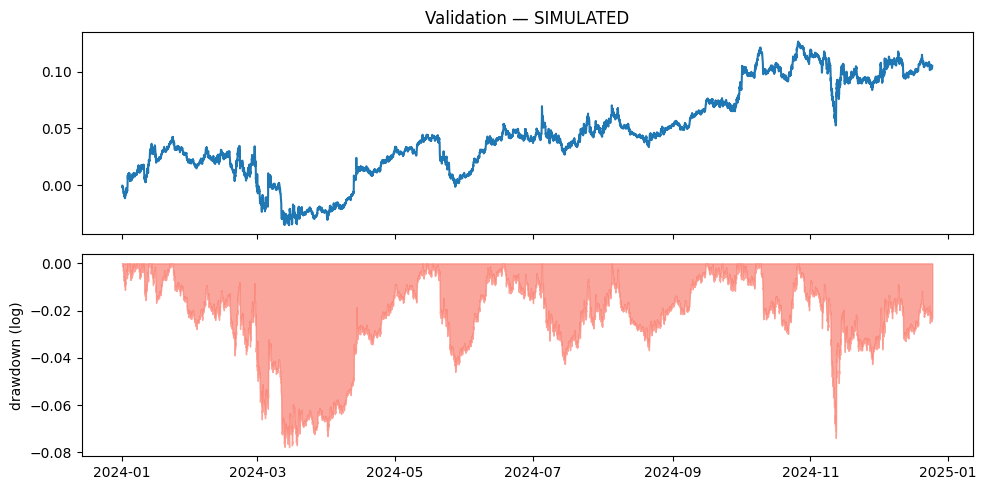

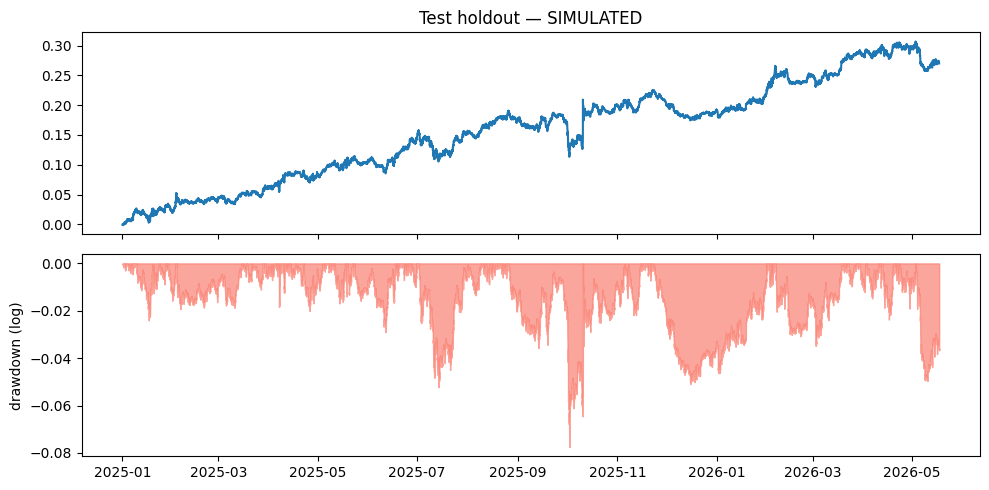

In [12]:
def plot_equity(bars, title):
    ts = pd.to_datetime(bars["timestamp"], utc=True)
    eq = equity_curve(bars["net"])
    dd = eq - eq.cummax()
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].plot(ts, eq)
    axes[0].set_title(title + " — SIMULATED")
    axes[1].fill_between(ts, dd, 0, color="salmon", alpha=0.7)
    axes[1].set_ylabel("drawdown (log)")
    plt.tight_layout()
    plt.show()

plot_equity(val_bars, "Validation")
plot_equity(test_bars, "Test holdout")


## 10. Stress scenarios (simulated)

In [13]:
stress = {
    "double_costs_test": hybrid_sleeve_metrics(
        cfg, exp, test_panel, exec_test, model, cfg.model_features,
        fee_mult=2.0, split="test (2× fees & slippage)",
    ),
    "val_h1_2024": stress_subperiod(val_bars, "2024-01-01", "2024-07-01", BPY),
}
stress["val_h1_2024"]["split"] = "validation H1 2024"
stress["val_h1_2024"]["max_dd_pct"] = stress["val_h1_2024"]["max_dd_log"] * 100

display(pd.DataFrame([fmt_table(stress["double_costs_test"]), fmt_table(stress["val_h1_2024"])]))


,split,cagr_%,ann_vol_%,sharpe,max_dd_%,turnover_ann,hit_rate,n_bars
0,test (2× fees & slippage),16.19,11.64,1.289,-8.22,23.318,0.512,12039
1,validation H1 2024,8.12,11.59,0.674,-7.78,NaN,0.505,4366


## 11. Simulated vs. live

| | This notebook | Live |
|---|---------------|------|
| Track record | **Simulated only** | None |
| Fills | Fixed fee/slip model | Latency, partial fills |
| Universe | Fixed 20 names | Survivorship bias |

**All CAGR, vol, Sharpe, drawdown, and turnover figures are hypothetical back-tests for coursework.**